In [1]:
import pandas as pd

df = pd.read_csv('../Datasets/HousePricePrediction.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None
                Id   MSSubClass        LotArea  OverallCond    YearBuilt  \
count  2919.000000  2919.000000    2919.000000  2919.000000  2919.000000   
mean   1459.000000    57.13

In [3]:
df = df.dropna(subset=["SalePrice"])

In [4]:
print(df.shape)

(1460, 13)


In [5]:
feature = "TotalBsmtSF"

X = df[[feature]]
y = df["SalePrice"]

In [6]:
data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[[feature]]
y = data["SalePrice"]

In [7]:
import numpy as np

X = X.values
y = y.values

print(X.shape)
print(y.shape)

(1460, 1)
(1460,)


**ACTUAL LINEAR REGRESSION**

In [8]:
# number of features
n_features = X.shape[1]

# initialize
w = np.zeros(n_features)
b = 0

print(w)
print(b)

[0.]
0


In [9]:
def predict(X, w, b):
    return np.dot(X, w) + b

In [10]:
y_pred = predict(X, w, b)

print(y_pred[:5])

[0. 0. 0. 0. 0.]


In [11]:
def compute_cost(y, y_pred):
    n = len(y)
    cost = (1/n) * np.sum((y - y_pred) ** 2)
    return cost

In [12]:
cost = compute_cost(y, y_pred)
print(cost)

39039267707.765755


In [13]:
def gradient_descent(X, y, w, b, learning_rate):
    n = len(y)
    
    y_pred = predict(X, w, b)
    
    dw = (1/n) * np.dot(X.T, (y_pred - y))
    db = (1/n) * np.sum(y_pred - y)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    return w, b

In [14]:
w, b = gradient_descent(X, y, w, b, learning_rate=0.00000001)

print(w, b)

[2.12681171] 0.0018092119589041096


In [15]:
epochs = 1000
learning_rate = 0.00000001

costs = []

for i in range(epochs):
    y_pred = predict(X, w, b)
    
    cost = compute_cost(y, y_pred)
    costs.append(cost)
    
    w, b = gradient_descent(X, y, w, b, learning_rate)
    
    if i % 100 == 0:
        print(f"Iteration {i}, Cost: {cost}")

Iteration 0, Cost: 38140529217.31384
Iteration 100, Cost: 6925964260.099313
Iteration 200, Cost: 4694668046.336257
Iteration 300, Cost: 4535169188.519228
Iteration 400, Cost: 4523767645.815284
Iteration 500, Cost: 4522952473.77199
Iteration 600, Cost: 4522894042.279226
Iteration 700, Cost: 4522889704.515057
Iteration 800, Cost: 4522889233.50747
Iteration 900, Cost: 4522889038.90547


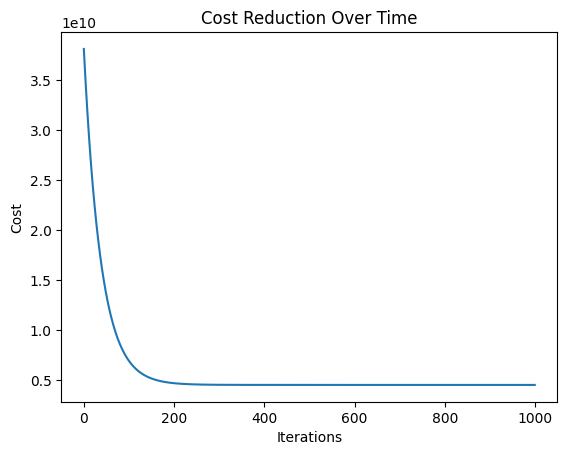

In [16]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.show()

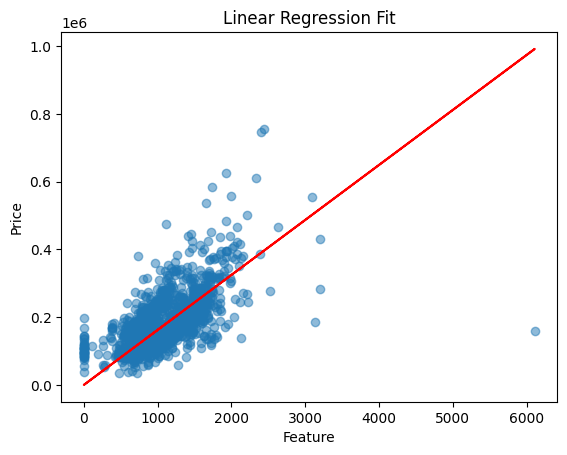

In [17]:
plt.scatter(X, y, alpha=0.5)
plt.plot(X, predict(X, w, b), color='red')
plt.xlabel("Feature")
plt.ylabel("Price")
plt.title("Linear Regression Fit")
plt.show()

In [18]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix["SalePrice"].sort_values(ascending=False))

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


In [19]:
features = ["TotalBsmtSF", "YearBuilt", "YearRemodAdd"]

In [20]:
X = df[features]
y = df["SalePrice"]

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[features]
y = data["SalePrice"]

In [21]:
X = X.values
y = y.values

In [22]:
print(X.shape)

(1460, 3)


In [23]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

In [24]:
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0

In [25]:
epochs = 1000
learning_rate = 0.01

costs = []

for i in range(epochs):
    y_pred = predict(X, w, b)
    
    cost = compute_cost(y, y_pred)
    costs.append(cost)
    
    w, b = gradient_descent(X, y, w, b, learning_rate)
    
    if i % 100 == 0:
        print(f"Iteration {i}, Cost: {cost}")

Iteration 0, Cost: 39039267707.765755
Iteration 100, Cost: 7584731457.426878
Iteration 200, Cost: 3667299770.067433
Iteration 300, Cost: 3143385623.336672
Iteration 400, Cost: 3071355790.366892
Iteration 500, Cost: 3061010163.5868545
Iteration 600, Cost: 3059354994.3231406
Iteration 700, Cost: 3059022010.4063053
Iteration 800, Cost: 3058929414.5338774
Iteration 900, Cost: 3058895809.051334


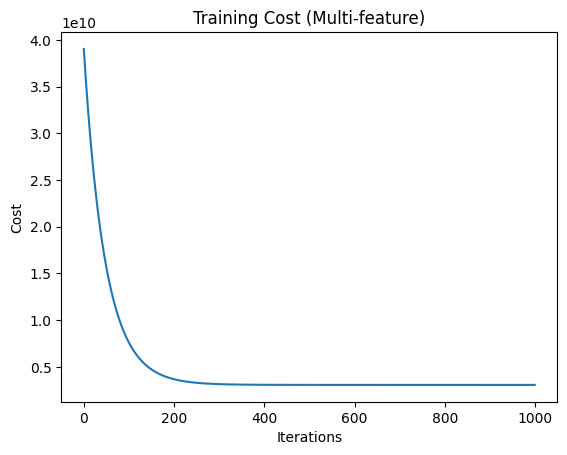

In [26]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost (Multi-feature)")
plt.show()

In [27]:
X = df[features]
y = df["SalePrice"]

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[features]
y = data["SalePrice"]

In [28]:
X = X.values
y = y.values

In [29]:
print(X.shape)

(1460, 3)


In [30]:
# number of samples
n = X.shape[0]

# shuffle indices
indices = np.random.permutation(n)

# split point
split = int(0.8 * n)

train_idx = indices[:split]
test_idx = indices[split:]

# create splits
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [31]:
print(X_train.shape, X_test.shape)

(1168, 3) (292, 3)


In [32]:
# Step 1: already split

# Step 2: compute from training only
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Step 3: scale both
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [33]:
# reinitialize
w = np.zeros(X_train.shape[1])
b = 0

costs = []

epochs = 1000
learning_rate = 0.01

for i in range(epochs):
    y_pred = predict(X_train, w, b)
    
    cost = compute_cost(y_train, y_pred)
    costs.append(cost)
    
    w, b = gradient_descent(X_train, y_train, w, b, learning_rate)

In [34]:
print(costs[-1])

3119128260.63999


In [35]:
y_test_pred = predict(X_test, w, b)

test_cost = compute_cost(y_test, y_test_pred)

print("Test Cost:", test_cost)

Test Cost: 2846875007.817874


In [36]:
def r2_score(y, y_pred):
    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)
    return 1 - (ss_residual / ss_total)

In [37]:
r2 = r2_score(y_test, y_test_pred)
print("R2 Score:", r2)

R2 Score: 0.56633109409276


**Stochastic Gradient Descent (SGD)**

In [38]:
w = np.zeros(X_train.shape[1])
b = 0

costs = []
learning_rate = 0.001


for i in range(epochs):
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]
    for j in range(len(X_train)):
        x_j = X_train[j].reshape(1, -1)
        y_j = y_train[j]
        
        y_pred = predict(x_j, w, b)
        
        # w, b = gradient_descent(x_j, np.array([y_j]), w, b, learning_rate)
        # print(w, b)
        # exit  # just one step for demonstration
        error = y_pred - y_j

        dw = x_j.T * error
        db = error

        w = w - learning_rate * dw.flatten()
        b = b - learning_rate * db
    
    # 🔥 compute cost on full training set
    full_pred = predict(X_train, w, b)
    cost = compute_cost(y_train, full_pred)
    costs.append(cost)
    
    if i % 50 == 0:
        print(f"Epoch {i}, Cost: {cost}")

Epoch 0, Cost: 6343791007.6600895
Epoch 50, Cost: 3119488471.603165
Epoch 100, Cost: 3119982930.7366652
Epoch 150, Cost: 3121311228.499911
Epoch 200, Cost: 3133731561.9202623
Epoch 250, Cost: 3120858229.9733415
Epoch 300, Cost: 3119681529.1959567
Epoch 350, Cost: 3119273058.169529
Epoch 400, Cost: 3120432283.6440444
Epoch 450, Cost: 3131349253.563218
Epoch 500, Cost: 3119729056.425344
Epoch 550, Cost: 3120548828.929463
Epoch 600, Cost: 3119510110.466396
Epoch 650, Cost: 3121153065.8484907
Epoch 700, Cost: 3128850641.778133
Epoch 750, Cost: 3123289916.617626
Epoch 800, Cost: 3119627912.793543
Epoch 850, Cost: 3120683559.5139475
Epoch 900, Cost: 3120040771.313123
Epoch 950, Cost: 3119425689.4031396


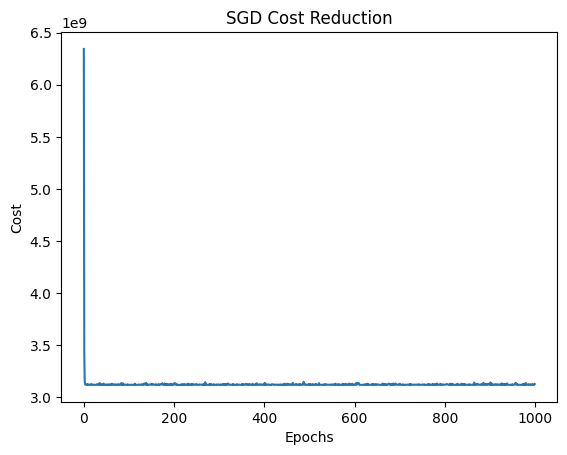

In [39]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("SGD Cost Reduction")
plt.show()

**Mini-batch Gradient Descent**

In [40]:
w = np.zeros(X_train.shape[1])
b = 0

costs = []
learning_rate = 0.005

batch_size = 32

for i in range(epochs):
    
    # shuffle
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]
    
    for j in range(0, len(X_train), batch_size):
        X_batch = X_train[j:j+batch_size]
        y_batch = y_train[j:j+batch_size]
        
        y_pred = predict(X_batch, w, b)
        
        error = y_pred - y_batch
        
        dw = (1/len(y_batch)) * np.dot(X_batch.T, error)
        db = (1/len(y_batch)) * np.sum(error)
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
    
    # track cost
    full_pred = predict(X_train, w, b)
    cost = compute_cost(y_train, full_pred)
    costs.append(cost)
    
    if i % 50 == 0:
        print(f"Epoch {i}, Cost: {cost}")
        
print("Final weights:", w)
print("Final bias:", b)

Epoch 0, Cost: 27626589499.937763
Epoch 50, Cost: 3119154106.8172708
Epoch 100, Cost: 3119129464.0631413
Epoch 150, Cost: 3119408266.027761
Epoch 200, Cost: 3119116064.26108
Epoch 250, Cost: 3119118492.2645106
Epoch 300, Cost: 3119152010.398186
Epoch 350, Cost: 3119128170.5217824
Epoch 400, Cost: 3119223436.5451593
Epoch 450, Cost: 3119137094.363587
Epoch 500, Cost: 3119127588.702002
Epoch 550, Cost: 3119251338.3502884
Epoch 600, Cost: 3119125206.044527
Epoch 650, Cost: 3119154574.5354047
Epoch 700, Cost: 3119229753.635131
Epoch 750, Cost: 3119140365.698737
Epoch 800, Cost: 3119119926.198391
Epoch 850, Cost: 3119220821.972295
Epoch 900, Cost: 3119131304.377123
Epoch 950, Cost: 3119136564.366346
Final weights: [36730.67490028 12986.67260757 21328.14787465]
Final bias: 182081.1205415705


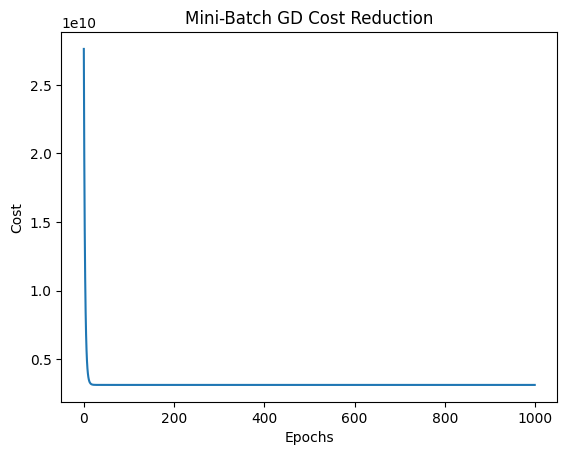

In [41]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Mini-Batch GD Cost Reduction")
plt.show()

GRAPHS PLOTTING

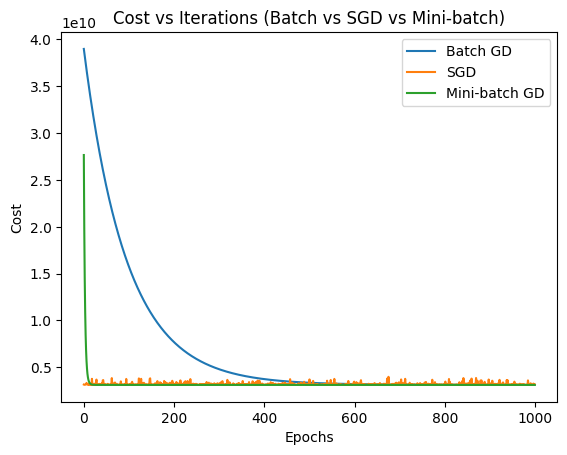

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- BATCH GD ----------
w = np.zeros(X_train.shape[1])
b = 0
batch_costs = []

for i in range(epochs):
    y_pred = predict(X_train, w, b)
    error = y_pred - y_train
    
    dw = (1/len(y_train)) * np.dot(X_train.T, error)
    db = (1/len(y_train)) * np.sum(error)
    
    w -= learning_rate * dw
    b -= learning_rate * db
    
    cost = compute_cost(y_train, predict(X_train, w, b))
    batch_costs.append(cost)


# ---------- SGD ----------
w = np.zeros(X_train.shape[1])
b = 0
sgd_costs = []

for i in range(epochs):
    indices = np.random.permutation(len(X_train))
    
    for j in indices:
        x_j = X_train[j].reshape(1, -1)
        y_j = y_train[j]
        
        y_pred = predict(x_j, w, b)
        error = y_pred - y_j
        
        dw = x_j.T * error
        db = error
        
        w -= learning_rate * dw.flatten()
        b -= learning_rate * db
    
    cost = compute_cost(y_train, predict(X_train, w, b))
    sgd_costs.append(cost)


# ---------- MINI-BATCH ----------
w = np.zeros(X_train.shape[1])
b = 0
mini_costs = []

batch_size = 32

for i in range(epochs):
    indices = np.random.permutation(len(X_train))
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    for j in range(0, len(X_train), batch_size):
        X_batch = X_shuffled[j:j+batch_size]
        y_batch = y_shuffled[j:j+batch_size]
        
        y_pred = predict(X_batch, w, b)
        error = y_pred - y_batch
        
        dw = (1/len(y_batch)) * np.dot(X_batch.T, error)
        db = (1/len(y_batch)) * np.sum(error)
        
        w -= learning_rate * dw
        b -= learning_rate * db
    
    cost = compute_cost(y_train, predict(X_train, w, b))
    mini_costs.append(cost)


# ---------- PLOT ----------
plt.plot(batch_costs, label="Batch GD")
plt.plot(sgd_costs, label="SGD")
plt.plot(mini_costs, label="Mini-batch GD")

plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Cost vs Iterations (Batch vs SGD vs Mini-batch)")
plt.legend()
plt.show()

**L2 Regularization (Ridge)**

In [43]:
def compute_cost_l2(y, y_pred, w, lambda_):
    n = len(y)
    
    mse = (1/n) * np.sum((y - y_pred) ** 2)
    reg = lambda_ * np.sum(w ** 2)
    
    return mse + reg

In [44]:
# Reinitialize (IMPORTANT)
w = np.zeros(X_train.shape[1])
b = 0

learning_rate = 0.005
batch_size = 32
lambda_ = 0.1

train_costs = []
val_costs = []

for i in range(epochs):
    
    # shuffle
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]
    
    for j in range(0, len(X_train), batch_size):
        X_batch = X_train[j:j+batch_size]
        y_batch = y_train[j:j+batch_size]
        
        y_pred = predict(X_batch, w, b)
        error = y_pred - y_batch
        
        # L2 gradient
        dw = (1/len(y_batch)) * np.dot(X_batch.T, error) + lambda_ * w
        db = (1/len(y_batch)) * np.sum(error)
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
    
    # 🔥 Training cost
    train_pred = predict(X_train, w, b)
    train_cost = compute_cost_l2(y_train, train_pred, w, lambda_)
    train_costs.append(train_cost)
    
    # 🔥 Validation cost (THIS was missing in your brain-fried version)
    val_pred = predict(X_test, w, b)
    val_cost = compute_cost_l2(y_test, val_pred, w, lambda_)
    val_costs.append(val_cost)
    
    if i % 50 == 0:
        print(f"Epoch {i}, Train: {train_cost}, Val: {val_cost}")

print("Final weights:", w)
print("Final bias:", b)
print("Norm:", np.linalg.norm(w))

Epoch 0, Train: 27693869663.233337, Val: 26348567959.375706
Epoch 50, Train: 3302125441.454537, Val: 3091871305.669856
Epoch 100, Train: 3301855798.8684235, Val: 3084393274.3324347
Epoch 150, Train: 3301908073.5878634, Val: 3078105609.017894
Epoch 200, Train: 3301897033.6619883, Val: 3086801842.1326327
Epoch 250, Train: 3301885595.4703884, Val: 3086263932.699786
Epoch 300, Train: 3301845777.50637, Val: 3082181177.446817
Epoch 350, Train: 3302162432.32927, Val: 3073752516.721482
Epoch 400, Train: 3301919709.9380283, Val: 3078997625.5508504
Epoch 450, Train: 3302972418.6260657, Val: 3101044788.960928
Epoch 500, Train: 3301903054.939627, Val: 3079283883.376786
Epoch 550, Train: 3301857026.930854, Val: 3082191234.7528157
Epoch 600, Train: 3301977015.515778, Val: 3076718434.5521507
Epoch 650, Train: 3301916327.5621243, Val: 3082376686.8351817
Epoch 700, Train: 3301873291.3022556, Val: 3080384091.744062
Epoch 750, Train: 3301914246.5587916, Val: 3088631400.7510943
Epoch 800, Train: 330185140

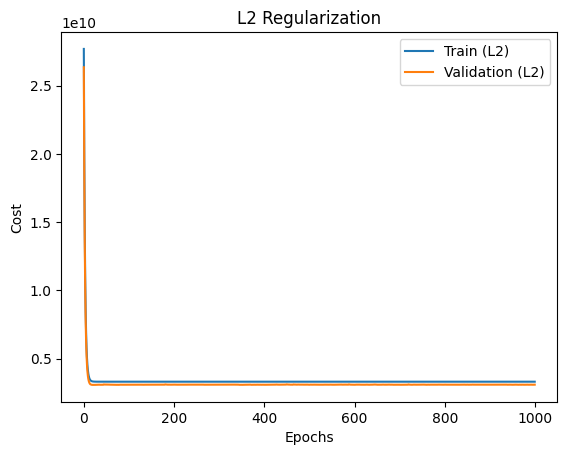

In [45]:
import matplotlib.pyplot as plt

plt.plot(train_costs, label="Train (L2)")
plt.plot(val_costs, label="Validation (L2)")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("L2 Regularization")
plt.legend()
plt.show()

**L1 Regularization (Lasso)**

In [46]:
def compute_cost_l1(y, y_pred, w, lambda_):
    n = len(y)
    
    mse = (1/n) * np.sum((y - y_pred) ** 2)
    reg = lambda_ * np.sum(np.abs(w))
    
    return mse + reg

In [47]:
# Adding Fake Feature (ONLY ONCE, careful not to repeat every run)
X_train = np.hstack([X_train, np.random.randn(X_train.shape[0], 1)])
X_test = np.hstack([X_test, np.random.randn(X_test.shape[0], 1)])  # ⚠️ add here too

In [48]:
# Initialize
w = np.zeros(X_train.shape[1])
b = 0
print("Initial w:", w)
learning_rate = 0.005
batch_size = 32
lambda_ = 500

train_costs = []
val_costs = []

for i in range(epochs):
    
    # shuffle
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]
    
    for j in range(0, len(X_train), batch_size):
        X_batch = X_train[j:j+batch_size]
        y_batch = y_train[j:j+batch_size]
        
        y_pred = predict(X_batch, w, b)
        
        error = y_pred - y_batch
        
        dw = (1/len(y_batch)) * np.dot(X_batch.T, error) + lambda_ * np.sign(w)
        db = (1/len(y_batch)) * np.sum(error)
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
    
    # 🔥 Training cost
    train_pred = predict(X_train, w, b)
    train_cost = compute_cost_l1(y_train, train_pred, w, lambda_)
    train_costs.append(train_cost)
    
    # 🔥 Validation cost (NEW)
    val_pred = predict(X_test, w, b)
    val_cost = compute_cost_l1(y_test, val_pred, w, lambda_)
    val_costs.append(val_cost)
    
    if i % 50 == 0:
        print(f"Epoch {i}, Train Cost: {train_cost}, Val Cost: {val_cost}")

print("Final weights:", w)
print("Final bias:", b)
print("Norm:", np.linalg.norm(w))

Initial w: [0. 0. 0. 0.]
Epoch 0, Train Cost: 27596444934.80528, Val Cost: 26303325822.195423
Epoch 50, Train Cost: 3153389156.104193, Val Cost: 2897980160.8230925
Epoch 100, Train Cost: 3153339751.024702, Val Cost: 2899865311.5711994
Epoch 150, Train Cost: 3153408168.870485, Val Cost: 2899789563.8070583
Epoch 200, Train Cost: 3153363285.688983, Val Cost: 2899551038.470268
Epoch 250, Train Cost: 3153700193.854827, Val Cost: 2909649191.3988643
Epoch 300, Train Cost: 3153395191.746919, Val Cost: 2896280739.6133432
Epoch 350, Train Cost: 3153524105.4314466, Val Cost: 2900785819.7383785
Epoch 400, Train Cost: 3153382192.963966, Val Cost: 2901388229.1786213
Epoch 450, Train Cost: 3153552114.5248437, Val Cost: 2908877955.912916
Epoch 500, Train Cost: 3153568161.6410646, Val Cost: 2905032816.3518887
Epoch 550, Train Cost: 3153722348.324431, Val Cost: 2908621958.227121
Epoch 600, Train Cost: 3153511952.9360857, Val Cost: 2904400681.644714
Epoch 650, Train Cost: 3153526686.6777306, Val Cost: 29

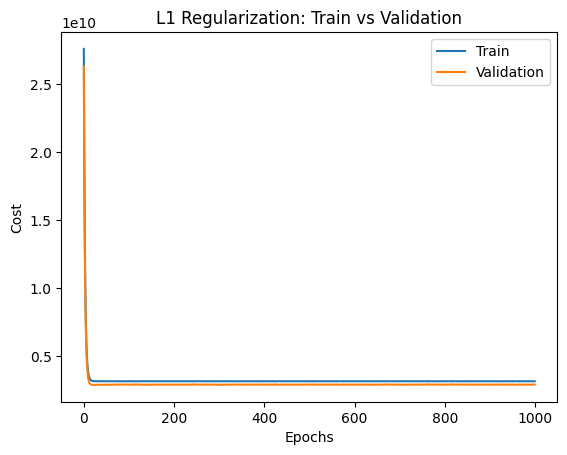

In [49]:
import matplotlib.pyplot as plt

plt.plot(train_costs, label="Train")
plt.plot(val_costs, label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("L1 Regularization: Train vs Validation")
plt.legend()
plt.show()

In [ ]:
print("Weights Without Reg: [39187, 13589, 20110]")
print("Weights With L1:     [37098, 13515, 21916, ~31]")

Without Reg: [39187, 13589, 20110]
With L1:     [37098, 13515, 21916, ~31]
